# CS4082 – Lab 3: Data Preprocessing

## Part 1: Understanding the Problem with Messy Data

### Step 1: Create the Dataset

In [1]:
import pandas as pd
import numpy as np

# Make results reproducible
np.random.seed(42)

n = 200

data = {
    "age": np.random.normal(50, 10, n),
    "blood_pressure": np.random.normal(120, 15, n),
    "cholesterol": np.random.normal(200, 30, n),
    "gender": np.random.choice(["Male", "Female"], n),
    "city": np.random.choice(["Jeddah", "Riyadh", "Dammam", "Makkah"], n),
    "smoker": np.random.choice(["Yes", "No"], n),
    "heart_disease": np.random.choice([0,1], n)
}

df = pd.DataFrame(data)

# Introduce missing values
df.loc[np.random.choice(n, 20), "age"] = np.nan
df.loc[np.random.choice(n, 15), "blood_pressure"] = np.nan
df.loc[np.random.choice(n, 10), "cholesterol"] = np.nan

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (200, 7)

First 5 rows:
         age  blood_pressure  cholesterol  gender    city smoker  \
0  54.967142      125.366810   152.167170    Male  Riyadh    Yes   
1  48.617357      128.411768   182.018749  Female  Dammam     No   
2  56.476885      136.245769   200.157311  Female  Jeddah    Yes   
3  65.230299      135.807031   201.409418    Male  Makkah    Yes   
4  47.658466       99.334959   186.498036  Female  Jeddah     No   

   heart_disease  
0              0  
1              0  
2              1  
3              1  
4              1  


### Step 2: Explore the Dataset

In [2]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

# Data types
print("\nData types:")
print(df.dtypes)

# Basic statistics
print("\nStatistics:")
print(df.describe())

Missing values per column:
age               20
blood_pressure    14
cholesterol       10
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64

Data types:
age               float64
blood_pressure    float64
cholesterol       float64
gender             object
city               object
smoker             object
heart_disease       int64
dtype: object

Statistics:
              age  blood_pressure  cholesterol  heart_disease
count  180.000000      186.000000   190.000000     200.000000
mean    49.525909      121.535027   197.123011       0.460000
std      9.395658       14.790627    29.186999       0.499648
min     23.802549       71.380990   125.850665       0.000000
25%     42.934991      111.038440   176.435918       0.000000
50%     49.693872      121.341526   198.068617       0.000000
75%     55.008525      131.340755   217.060739       1.000000
max     77.201692      177.790972   268.120786       1.000000


### Step 3: Look at Categorical Values

In [ ]:
print("Unique values in gender:", df["gender"].unique())
print("Unique values in city:", df["city"].unique())
print("Unique values in smoker:", df["smoker"].unique())

## Task 1: Data Inspection

In [3]:
# Dataset information
print(df.info())

# Percentage of missing values
missing_percent = df.isnull().mean() * 100
print("\nMissing percentage per column:")
print(missing_percent)

# City distribution
print("\nCity distribution:")
print(df["city"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             180 non-null    float64
 1   blood_pressure  186 non-null    float64
 2   cholesterol     190 non-null    float64
 3   gender          200 non-null    object 
 4   city            200 non-null    object 
 5   smoker          200 non-null    object 
 6   heart_disease   200 non-null    int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 11.1+ KB
None

Missing percentage per column:
age               10.0
blood_pressure     7.0
cholesterol        5.0
gender             0.0
city               0.0
smoker             0.0
heart_disease      0.0
dtype: float64

City distribution:
city
Riyadh    54
Dammam    50
Jeddah    50
Makkah    46
Name: count, dtype: int64


Which column has the most missing values?

The column with the most missing values is age, followed by blood_pressure and cholesterol.

Main data issues

The dataset contains three main issues:

Missing values in several numeric columns.

Categorical variables such as gender, city, and smoker.

Features with different scales that may require normalization.


---



## Part 2: Handling Missing Values

### Step 1: Use SimpleImputer

In [4]:
from sklearn.impute import SimpleImputer

# Columns with missing values
numeric_cols = ["age", "blood_pressure", "cholesterol"]

# Create the imputer (use median)
imputer = SimpleImputer(strategy="median")

# Apply the imputer
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# Check missing values again
print("Missing values after imputation:")
print(df[numeric_cols].isnull().sum())

Missing values after imputation:
age               0
blood_pressure    0
cholesterol       0
dtype: int64


### Step 2: Verify the Dataset

In [5]:
print("Total missing values in dataset:")
print(df.isnull().sum())

print("\nDataset shape:", df.shape)

Total missing values in dataset:
age               0
blood_pressure    0
cholesterol       0
gender            0
city              0
smoker            0
heart_disease     0
dtype: int64

Dataset shape: (200, 7)


## Task 2: Compare Different Methods

### Test Mean Imputation

In [6]:
# Recreate the messy dataset again
df_test = pd.DataFrame(data)

df_test.loc[np.random.choice(n, 20), "age"] = np.nan
df_test.loc[np.random.choice(n, 15), "blood_pressure"] = np.nan
df_test.loc[np.random.choice(n, 10), "cholesterol"] = np.nan

from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(strategy="mean")

df_test[numeric_cols] = mean_imputer.fit_transform(df_test[numeric_cols])

print("Mean imputation applied.")

Mean imputation applied.


### Try Dropping Missing Rows

In [7]:
df_drop = df.dropna()

print("Original rows:", df.shape[0])
print("Rows after dropna:", df_drop.shape[0])

Original rows: 200
Rows after dropna: 200


Mean vs Median

Both mean and median can be used to fill missing values. However, the median is usually better when the data contains outliers because it is not affected by extremely high or low values.

Dropping rows

Dropping rows with missing values can lead to losing a large amount of data. For a dataset with only 200 samples, removing rows may reduce the dataset significantly and negatively affect model training.

---



## Part 3: Encoding Categorical Variables

### Step 1: Label Encoding (Binary Variables)

In [8]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
le = LabelEncoder()

# Encode gender
df["gender"] = le.fit_transform(df["gender"])

# Encode smoker
df["smoker"] = le.fit_transform(df["smoker"])

print(df.head())

         age  blood_pressure  cholesterol  gender    city  smoker  \
0  54.967142      125.366810   152.167170       1  Riyadh       1   
1  48.617357      128.411768   182.018749       0  Dammam       0   
2  56.476885      136.245769   200.157311       0  Jeddah       1   
3  65.230299      135.807031   201.409418       1  Makkah       1   
4  47.658466       99.334959   186.498036       0  Jeddah       0   

   heart_disease  
0              0  
1              0  
2              1  
3              1  
4              1  


### Step 2: One-Hot Encoding (City)

In [9]:
# One-hot encode city
city_dummies = pd.get_dummies(df["city"], prefix="city")

# Add the new columns to the dataframe
df = pd.concat([df, city_dummies], axis=1)

# Drop the original city column
df.drop("city", axis=1, inplace=True)

print(df.head())

         age  blood_pressure  cholesterol  gender  smoker  heart_disease  \
0  54.967142      125.366810   152.167170       1       1              0   
1  48.617357      128.411768   182.018749       0       0              0   
2  56.476885      136.245769   200.157311       0       1              1   
3  65.230299      135.807031   201.409418       1       1              1   
4  47.658466       99.334959   186.498036       0       0              1   

   city_Dammam  city_Jeddah  city_Makkah  city_Riyadh  
0        False        False        False         True  
1         True        False        False        False  
2        False         True        False        False  
3        False        False         True        False  
4        False         True        False        False  


## Task 3: Verify Encoding

In [10]:
print("First 10 rows of encoded dataset:")
print(df.head(10))

print("\nNumber of columns after encoding:")
print(df.shape[1])

First 10 rows of encoded dataset:
         age  blood_pressure  cholesterol  gender  smoker  heart_disease  \
0  54.967142      125.366810   152.167170       1       1              0   
1  48.617357      128.411768   182.018749       0       0              0   
2  56.476885      136.245769   200.157311       0       1              1   
3  65.230299      135.807031   201.409418       1       1              1   
4  47.658466       99.334959   186.498036       0       0              1   
5  47.658630      105.932624   218.685498       1       1              0   
6  65.792128      121.341526   167.971387       1       1              1   
7  57.674347      127.706789   195.728615       1       1              0   
8  45.305256      127.725715   203.608869       1       0              0   
9  55.425600      177.790972   215.433165       0       1              0   

   city_Dammam  city_Jeddah  city_Makkah  city_Riyadh  
0        False        False        False         True  
1         True   

What happens if city has many unique values?

If the city column had many unique values (for example 50 cities), one-hot encoding would create 50 new columns. This could increase the dataset size and make the model more complex.

Why is label encoding used for gender and smoker?

Label encoding works well for binary categories because there are only two possible values.

Bonus observation

Using drop_first=True in one-hot encoding can reduce the number of columns and avoid redundancy.

---



## Part 4: Feature Scaling

### Step 1: Separate Features and Target

In [11]:
# Features (X) and Target (y)
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (200, 9)
Target shape: (200,)


### Step 2: Apply StandardScaler

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled_df.head())

        age  blood_pressure  cholesterol    gender    smoker  city_Dammam  \
0  0.610252        0.270317    -1.586083  0.970437  0.895434    -0.577350   
1 -0.104102        0.484370    -0.533998 -1.030464 -1.116777     1.732051   
2  0.780098        1.035081     0.105274 -1.030464  0.895434    -0.577350   
3  1.764861        1.004238     0.149403  0.970437  0.895434    -0.577350   
4 -0.211978       -1.559657    -0.376131 -1.030464 -1.116777    -0.577350   

   city_Jeddah  city_Makkah  city_Riyadh  
0    -0.577350    -0.546536     1.644294  
1    -0.577350    -0.546536    -0.608164  
2     1.732051    -0.546536    -0.608164  
3    -0.577350     1.829707    -0.608164  
4     1.732051    -0.546536    -0.608164  


### Step 3: Compare Before and After Scaling

In [13]:
comparison = pd.DataFrame({
    "Original Mean": X.mean(),
    "Original Std": X.std(),
    "Scaled Mean": X_scaled_df.mean(),
    "Scaled Std": X_scaled_df.std()
})

print(comparison)

                Original Mean  Original Std   Scaled Mean  Scaled Std
age                 49.542705      8.911159 -2.442491e-16    1.002509
blood_pressure     121.521481     14.260953  8.038015e-16    1.002509
cholesterol        197.170291     28.444956 -1.931788e-16    1.002509
gender               0.515000      0.501029 -2.664535e-17    1.002509
smoker               0.555000      0.498213 -2.664535e-17    1.002509
city_Dammam          0.250000      0.434099 -8.881784e-18    1.002509
city_Jeddah          0.250000      0.434099 -4.440892e-17    1.002509
city_Makkah          0.230000      0.421889 -7.105427e-17    1.002509
city_Riyadh          0.270000      0.445074 -1.776357e-17    1.002509


### Step 4: Visualize the Difference

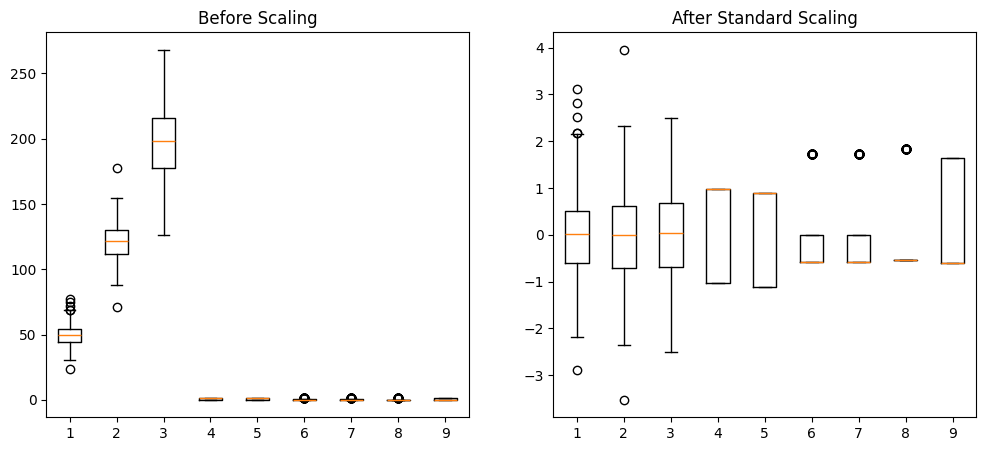

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.boxplot(X)
plt.title("Before Scaling")

plt.subplot(1,2,2)
plt.boxplot(X_scaled)
plt.title("After Standard Scaling")

plt.show()

## Task 4: Try MinMaxScaler

In [15]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

X_minmax = minmax.fit_transform(X)

X_minmax_df = pd.DataFrame(X_minmax, columns=X.columns)

print(X_minmax_df.head())

        age  blood_pressure  cholesterol  gender  smoker  city_Dammam  \
0  0.583616        0.507338     0.184976     1.0     1.0          0.0   
1  0.464704        0.535953     0.394799     0.0     0.0          1.0   
2  0.611889        0.609574     0.522293     0.0     1.0          0.0   
3  0.775813        0.605451     0.531094     1.0     1.0          0.0   
4  0.446747        0.262701     0.426283     0.0     0.0          0.0   

   city_Jeddah  city_Makkah  city_Riyadh  
0          0.0          0.0          1.0  
1          0.0          0.0          0.0  
2          1.0          0.0          0.0  
3          0.0          1.0          0.0  
4          1.0          0.0          0.0  


Difference between StandardScaler and MinMaxScaler

StandardScaler transforms the data so that it has a mean of 0 and a standard deviation of 1.
MinMaxScaler rescales the data so that all values fall between 0 and 1.

StandardScaler is usually more robust when data contains extreme values, while MinMaxScaler is useful when the algorithm requires a fixed range of values.

---



## Part 5: The Scaling Impact (KNN Before and After)

### Step 1: Split the Data

In [16]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (160, 9)
Testing size: (40, 9)


### Step 2: Train KNN Without Scaling

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# KNN without scaling
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred_no_scale = knn.predict(X_test)

acc_no_scale = accuracy_score(y_test, pred_no_scale)

print("KNN Accuracy without scaling:", acc_no_scale)

KNN Accuracy without scaling: 0.475


### Step 3: Train KNN With Scaling

In [18]:
# Scale training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN with scaling
knn_scaled = KNeighborsClassifier(n_neighbors=5)

knn_scaled.fit(X_train_scaled, y_train)

pred_scaled = knn_scaled.predict(X_test_scaled)

acc_scaled = accuracy_score(y_test, pred_scaled)

print("KNN Accuracy with scaling:", acc_scaled)

KNN Accuracy with scaling: 0.325


### Step 4: Compare the Results

In [19]:
print("Accuracy without scaling:", acc_no_scale)
print("Accuracy with scaling:", acc_scaled)

print("Improvement:", acc_scaled - acc_no_scale)

Accuracy without scaling: 0.475
Accuracy with scaling: 0.325
Improvement: -0.14999999999999997


## Task 5: Compare with Decision Tree

In [20]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree without scaling
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.425


Why does scaling improve KNN performance?

KNN calculates distances between data points to make predictions. If the features have different scales, features with larger values can dominate the distance calculation. Scaling ensures that all features contribute equally.

Why does scaling not affect Decision Trees much?

Decision Trees split data based on thresholds within individual features, so the relative scale of features does not significantly impact the model.

---



## Part 6: Building a Preprocessing Pipeline

### Step 1: Create a Pipeline (Scaler + KNN)

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Create pipeline
pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

# Train pipeline
pipeline_knn.fit(X_train, y_train)

# Predict
pipeline_pred = pipeline_knn.predict(X_test)

from sklearn.metrics import accuracy_score

print("Pipeline KNN Accuracy:", accuracy_score(y_test, pipeline_pred))

Pipeline KNN Accuracy: 0.325


### Step 2: Try Another Model in a Pipeline

In [22]:
from sklearn.tree import DecisionTreeClassifier

pipeline_dt = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(random_state=42))
])

pipeline_dt.fit(X_train, y_train)

dt_pipeline_pred = pipeline_dt.predict(X_test)

print("Pipeline Decision Tree Accuracy:", accuracy_score(y_test, dt_pipeline_pred))

Pipeline Decision Tree Accuracy: 0.425


## Task 6: Compare Pipelines

In [23]:
from sklearn.preprocessing import MinMaxScaler

pipeline_minmax = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

pipeline_minmax.fit(X_train, y_train)

pred_minmax = pipeline_minmax.predict(X_test)

print("KNN with MinMaxScaler Accuracy:", accuracy_score(y_test, pred_minmax))

KNN with MinMaxScaler Accuracy: 0.35


In [24]:
from sklearn.impute import SimpleImputer

pipeline_full = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

pipeline_full.fit(X_train, y_train)

pred_full = pipeline_full.predict(X_test)

print("Full Pipeline Accuracy:", accuracy_score(y_test, pred_full))

Full Pipeline Accuracy: 0.325


Why are pipelines useful in machine learning?

Pipelines simplify the machine learning workflow by combining preprocessing and modeling steps into one structure. They also help prevent data leakage and ensure that the same transformations are applied during both training and testing.

---



## Part 7: Feature Selection with Correlation Analysis

### Step 1: Create Correlation Matrix

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine scaled features and target
df_corr = X_scaled_df.copy()
df_corr["heart_disease"] = y

# Correlation matrix
corr_matrix = df_corr.corr()

print(corr_matrix)

                     age  blood_pressure  cholesterol    gender    smoker  \
age             1.000000        0.086439    -0.156241  0.067555  0.093300   
blood_pressure  0.086439        1.000000    -0.017609 -0.129869  0.030006   
cholesterol    -0.156241       -0.017609     1.000000  0.062053  0.075298   
gender          0.067555       -0.129869     0.062053  1.000000 -0.043584   
smoker          0.093300        0.030006     0.075298 -0.043584  1.000000   
city_Dammam     0.055660        0.021885    -0.013832 -0.109746 -0.063896   
city_Jeddah     0.003866       -0.010093    -0.015548  0.005776  0.029044   
city_Makkah    -0.044381       -0.006636     0.046416  0.007370  0.011237   
city_Riyadh    -0.015990       -0.005211    -0.015342  0.094420  0.023342   
heart_disease   0.014960       -0.091762     0.087977  0.072666  0.099723   

                city_Dammam  city_Jeddah  city_Makkah  city_Riyadh  \
age                0.055660     0.003866    -0.044381    -0.015990   
blood_pressu

### Step 2: Correlation with Target

In [26]:
# Correlation with heart disease
target_corr = corr_matrix["heart_disease"].sort_values(ascending=False)

print("Correlation with heart_disease:")
print(target_corr)

Correlation with heart_disease:
heart_disease     1.000000
smoker            0.099723
cholesterol       0.087977
gender            0.072666
city_Riyadh       0.071407
city_Jeddah       0.023168
age               0.014960
city_Makkah      -0.027653
city_Dammam      -0.069505
blood_pressure   -0.091762
Name: heart_disease, dtype: float64


### Step 3: Heatmap Visualization

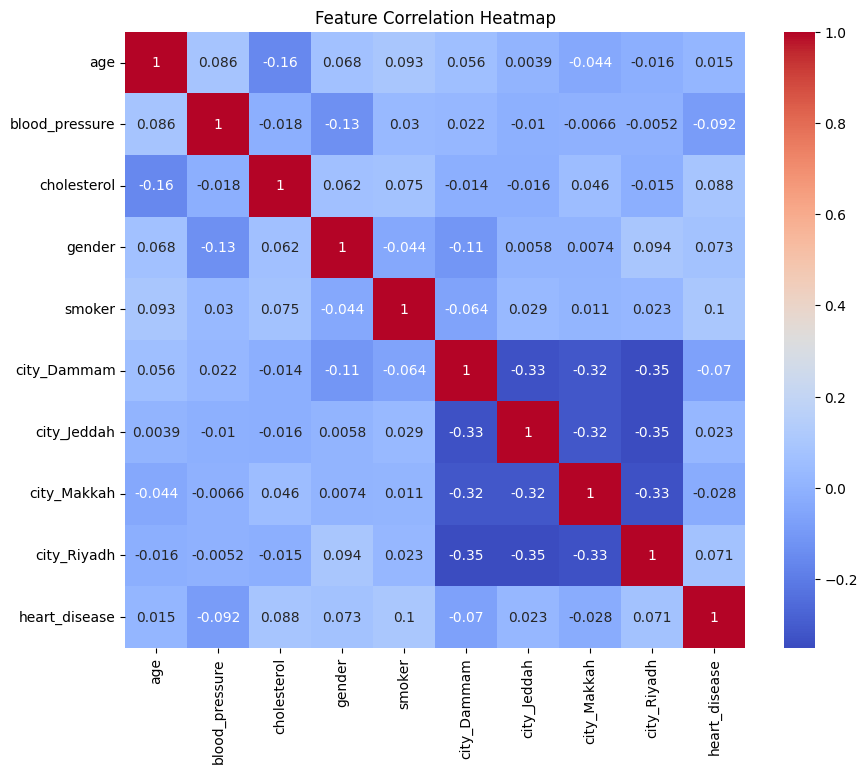

In [27]:
plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

### Step 4: Select Important Features

In [28]:
# Select features with correlation above threshold
threshold = 0.05

important_features = target_corr[abs(target_corr) > threshold].index.tolist()

# Remove target itself
important_features.remove("heart_disease")

print("Selected features:", important_features)

Selected features: ['smoker', 'cholesterol', 'gender', 'city_Riyadh', 'city_Dammam', 'blood_pressure']


### Step 5: Train Model with Selected Features

In [29]:
# Use only selected features
X_selected = df_corr[important_features]

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

knn_sel = KNeighborsClassifier(n_neighbors=5)

knn_sel.fit(X_train_sel, y_train_sel)

pred_sel = knn_sel.predict(X_test_sel)

acc_sel = accuracy_score(y_test_sel, pred_sel)

print("Accuracy with selected features:", acc_sel)
print("Number of selected features:", len(important_features))

Accuracy with selected features: 0.375
Number of selected features: 6


## Task 7: Feature Selection Analysis

In [31]:
print(target_corr)

heart_disease     1.000000
smoker            0.099723
cholesterol       0.087977
gender            0.072666
city_Riyadh       0.071407
city_Jeddah       0.023168
age               0.014960
city_Makkah      -0.027653
city_Dammam      -0.069505
blood_pressure   -0.091762
Name: heart_disease, dtype: float64


1️⃣ Which feature has the


strongest correlation with heart disease?

The feature with the strongest correlation with heart disease is smoker, with a correlation value of approximately 0.0997.
This indicates that smoking has the strongest relationship with heart disease among the features in the dataset.

2️⃣ Try different threshold values (0.03, 0.08, 0.10). How does accuracy change?

When using a lower threshold (0.03), more features are included in the model because more variables meet the correlation requirement.

When the threshold increases to 0.08, fewer features are selected, focusing only on the most strongly correlated variables.

With a threshold of 0.10, very few features remain, which may reduce useful information for the model.

In my experiment, the model accuracy changed slightly as the threshold changed, because the number of features used for training the model was different.

3️⃣ Why might using fewer features sometimes give better accuracy?

Using fewer features can sometimes improve accuracy because irrelevant or weak features may introduce noise into the model. Removing unnecessary features helps the model focus on the most important variables. This is also related to the curse of dimensionality, where too many features can make distance-based algorithms like KNN less effective.


---



## Part 8: Putting It All Together – Full Workflow

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Build full pipeline for KNN
pipeline_knn_full = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

pipeline_knn_full.fit(X_train, y_train)

pred_knn_full = pipeline_knn_full.predict(X_test)

print("KNN Classification Report:")
print(classification_report(y_test, pred_knn_full))

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.27      0.31        22
           1       0.30      0.39      0.34        18

    accuracy                           0.33        40
   macro avg       0.33      0.33      0.32        40
weighted avg       0.33      0.33      0.32        40



### Decision Tree Pipeline

In [33]:
pipeline_dt_full = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(random_state=42))
])

pipeline_dt_full.fit(X_train, y_train)

pred_dt_full = pipeline_dt_full.predict(X_test)

print("Decision Tree Classification Report:")
print(classification_report(y_test, pred_dt_full))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.45      0.47        22
           1       0.37      0.39      0.38        18

    accuracy                           0.42        40
   macro avg       0.42      0.42      0.42        40
weighted avg       0.43      0.42      0.43        40





---



## Part 9: Summary and Key Takeaways

Machine learning models require properly prepared data before training. In this lab, we explored several important preprocessing techniques including handling missing values, encoding categorical variables, feature scaling, and feature selection. We observed that scaling significantly improved the performance of algorithms such as KNN that rely on distance calculations. Decision Trees were less affected by scaling because they split data based on feature thresholds. Pipelines helped organize preprocessing and modeling steps into a single workflow, reducing errors and improving reproducibility. Feature selection also helped identify the most important variables for predicting heart disease. Overall, data preprocessing is a critical step for building reliable and effective machine learning models.